# Calculate Precision@10 and nDCG@10

Skenario SP-1 -> Precision@10: 1.00 | nDCG@10: 0.976
Skenario WC-1 -> Precision@10: 1.00 | nDCG@10: 1.000
Skenario SP-2 -> Precision@10: 0.70 | nDCG@10: 0.934
Skenario WC-2 -> Precision@10: 0.70 | nDCG@10: 0.947
Skenario SP-3 -> Precision@10: 0.60 | nDCG@10: 0.908
Skenario SP-4 -> Precision@10: 0.60 | nDCG@10: 0.861
Skenario WC-3 -> Precision@10: 1.00 | nDCG@10: 0.932
Skenario WC-4 -> Precision@10: 0.60 | nDCG@10: 0.935
Skenario SP-5 -> Precision@10: 0.80 | nDCG@10: 0.940
Skenario WC-5 -> Precision@10: 0.80 | nDCG@10: 0.990
-------------------------------------------------------
RATA-RATA     -> Precision@10: 0.78 | nDCG@10: 0.942


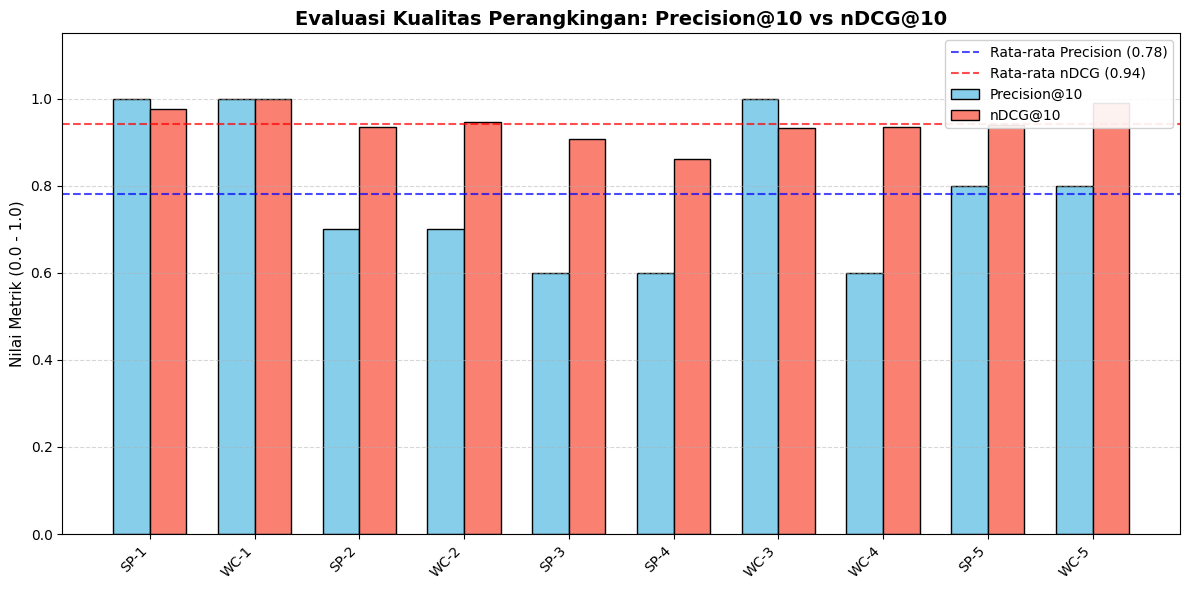

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = 'Model Evaluation.xlsx'

df_prec = pd.read_excel(file_path, sheet_name='Precision@10')
df_ndcg = pd.read_excel(file_path, sheet_name='nDCG@10')

scenarios = df_prec['Scenario ID'].dropna().tolist()[:10]

# KALKULASI PRECISION@10
# Mengambil matriks nilai biner (1/0)
prec_scores = df_prec.iloc[:10, 1:11].values

# Precision@K = (Total Item Relevan) / K
prec_at_10 = np.sum(prec_scores, axis=1) / 10
avg_prec = np.mean(prec_at_10)

# 3. KALKULASI nDCG@10
# Mengambil matriks nilai relevansi (0, 1, 2, 3)
ndcg_scores = df_ndcg.iloc[:10, 1:11].values

def dcg_at_k(r, k):
    """Menghitung Discounted Cumulative Gain (DCG)"""
    r = np.asarray(r)[:k]
    if r.size:
        # log basis 2 sebagai faktor diskon penalti peringkat
        return np.sum(r / np.log2(np.arange(2, r.size + 2)))
    return 0.

def ndcg_at_k(r, k):
    """Menghitung Normalized DCG (nDCG)"""
    dcg = dcg_at_k(r, k)
    # Mengurutkan skor aktual dari tertinggi ke terendah (Ideal DCG)
    ideal_r = np.sort(r)[::-1] 
    idcg = dcg_at_k(ideal_r, k)
    
    if not idcg:
        return 0.
    return dcg / idcg

ndcg_at_10 = [ndcg_at_k(row, 10) for row in ndcg_scores]
avg_ndcg = np.mean(ndcg_at_10)

for i, sc in enumerate(scenarios):
    print(f"Skenario {sc: <4} -> Precision@10: {prec_at_10[i]:.2f} | nDCG@10: {ndcg_at_10[i]:.3f}")
print("-" * 55)
print(f"RATA-RATA     -> Precision@10: {avg_prec:.2f} | nDCG@10: {avg_ndcg:.3f}")

# VISUALISASI
x = np.arange(len(scenarios))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, prec_at_10, width, label='Precision@10', color='#87CEEB', edgecolor='black')
rects2 = ax.bar(x + width/2, ndcg_at_10, width, label='nDCG@10', color='#FA8072', edgecolor='black')

ax.axhline(y=avg_prec, color='blue', linestyle='--', alpha=0.7, label=f'Rata-rata Precision ({avg_prec:.2f})')
ax.axhline(y=avg_ndcg, color='red', linestyle='--', alpha=0.7, label=f'Rata-rata nDCG ({avg_ndcg:.2f})')

ax.set_ylabel('Nilai Metrik (0.0 - 1.0)', fontsize=11)
ax.set_title('Evaluasi Kualitas Perangkingan: Precision@10 vs nDCG@10', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(scenarios, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 1.15) 
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('grafik_evaluasi_model.png', dpi=300)
plt.show()